


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.




## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Primeiro, vou abrir os cinco arquivos e observar a estrutura de cada tabela para entender melhor os dados. Depois, vou verificar se os tipos das colunas estão corretos, se existem valores ausentes e se há linhas duplicadas.

Em seguida, vou tratar esses problemas de acordo com o que fizer mais sentido em cada caso, explicando as decisões tomadas. Por fim, vou conferir se os dados ficaram organizados e prontos para a análise exploratória.

In [1]:
# Importe a biblioteca e leia o instacart_orders.csv com o separador correto
import pandas as pd
instacart_orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
print(instacart_orders.head())

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  


In [2]:
#Analisar quantas linhas, colunas, nomes, tipos de dados e sem ter espaços vazios
instacart_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [3]:
#DataFrame contendo apenas linhas onde days_since_prior_order é nulo
instacart_orders[instacart_orders['days_since_prior_order'].isna()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [4]:

# Filtra as linhas em que o pedido anterior foi feito há 1 dia
# e seleciona apenas a coluna 'order_number'
instacart_orders[instacart_orders['days_since_prior_order'] == 1] ['order_number']


19        29
56        18
66        86
68        21
113       10
          ..
478875    33
478885    35
478889    56
478899    91
478911    74
Name: order_number, Length: 20179, dtype: int64

In [5]:
# Filtra as linhas onde 'days_since_prior_order' está vazio (NaN)
# e retorna apenas a coluna 'order_number'
instacart_orders[instacart_orders['days_since_prior_order'].isna()]['order_number']

28        1
96        1
100       1
103       1
104       1
         ..
478895    1
478896    1
478922    1
478926    1
478945    1
Name: order_number, Length: 28819, dtype: int64

In [6]:
# Importe a biblioteca e leia o products.csv com o separador correto
import pandas as pd

products = pd.read_csv('/datasets/products.csv', sep=';')
print(products.head())

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  


In [7]:
#Analisar quantas linhas, colunas, nomes, tipos de dados e sem ter espaços vazios
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [8]:
#DataFrame contendo apenas linhas onde product_name é nulo
products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


In [9]:
#mostrar todos os valores únicos de aisle_id presentes nessas linhas com nome de produto ausente
products[products['product_name'].isna()]['aisle_id'].unique()

array([100])

In [10]:
#mostrar todos os valores únicos de department_id presentes nessas linhas com nome de produto ausente
products[products['product_name'].isna()]['department_id'].unique()

array([21])

In [11]:
# Importe a biblioteca e leia o aisles.csv com o separador correto
import pandas as pd

aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
print(aisles.head())

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


In [12]:
# Seleciona o island com aisle_id igual a 100
aisles[aisles['aisle_id'] == 100]

,aisle_id,aisle
99,100,missing


In [13]:
#Analisar quantas linhas, colunas, nomes, tipos de dados e sem ter espaços vazios
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [14]:
# Importe a biblioteca e leia o departments.csv com o separador correto
import pandas as pd

departments = pd.read_csv('/datasets/departments.csv', sep=';')
print(departments.head())

   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol


In [15]:
#Conferir se não há espaços extras ou diferença de maiúsculas/minúsculas
departments.columns

Index(['department_id', 'department'], dtype='object')

In [16]:
# Filtra as linhas onde 'departments' está vazio (NaN)
# e retorna apenas a coluna 'department_id'
departments[departments['department_id'].isna()]['department']

Series([], Name: department, dtype: object)

In [17]:
#Analisar quantas linhas, colunas, nomes, tipos de dados e sem ter espaços vazios
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [18]:
# Importe a biblioteca e leia o order_products.csv com o separador correto
import pandas as pd

order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
print(order_products.head())

   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1


In [19]:
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusões

Na visão geral dos dados, foi possível observar que o projeto é composto por cinco tabelas relacionadas entre si por identificadores como instacart_orders, products, order_products, aisles e departments. Também foi possível notar que os arquivos precisaram de um separador específico sep=';' para serem carregados corretamente.

Além disso, a análise inicial mostrou que algumas tabelas podem conter valores ausentes e duplicados, e que foi necessário verificar os tipos de dados antes de começar a análise exploratória. De modo geral, os dados aparentam estar organizados, mas ainda precisam passar por nova etapa de limpeza e preparação.

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Nesta parte, vou procurar duplicados nas cinco tabelas usando .duplicated().sum(), para ver se existem linhas exatamente iguais.

Além disso, também vou verificar as colunas que deveriam ser únicas, como order_id na tabela de pedidos, product_id na de produtos, aisle_id na de corredores e department_id na de departamentos.

No caso da tabela order_products, o mais importante é olhar a combinação order_id e product_id, porque ela mostra qual produto está em qual pedido. Se essa combinação aparecer mais de uma vez, pode ser sinal de problema nos dados.

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [20]:
# Verificar se há pedidos duplicados
print(instacart_orders.duplicated().sum())

15


Há linhas duplicadas? Se sim, o que elas têm em comum?

Foram encontrados 5 pedidos duplicados na tabela instacart_orders. Como essas linhas são exatamente iguais, faz sentido removê-las para não contar o mesmo pedido mais de uma vez na análise.

In [21]:
# Com base nas suas conclusões,
instacart_orders[instacart_orders.duplicated(keep=False)]['order_dow'].value_counts()
# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras
instacart_orders[(instacart_orders['order_dow'] == 3) & (instacart_orders['order_hour_of_day'] == 2)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


O que esse resultado quer dizer?

Esse resultado mostra que existem 121 pedidos feitos na quarta-feira às 2h da manhã. Então, apesar de as duplicatas aparecerem nesse mesmo dia e horário, elas são só uma parte desse total e não todos os pedidos desse grupo.

In [22]:
# Remova pedidos duplicados
instacart_orders = instacart_orders.drop_duplicates().reset_index(drop=True)

In [23]:
# Verifique as linhas duplicadas mais uma vez
instacart_orders.duplicated().sum()

0

In [24]:
# Verifique novamente apenas os IDs de pedidos duplicados
instacart_orders.duplicated(subset=['order_id']).sum()

0

Descreva brevemente suas conclusões e o que você fez com elas.

Removi as linhas duplicadas de instacart_orders e resetei o índice. Depois, conferi de novo os duplicados completos e os order_id, e não sobrou nenhuma repetição. Isso mostra que a tabela ficou limpa nessa parte.

### DataFrame `products`

In [25]:
# Verifique se há linhas completamente duplicadas
products.duplicated().sum()

0

In [26]:
# Verifique apenas IDs dos produtos duplicados
products.duplicated(subset=['product_id']).sum()

0

In [27]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)
products['product_name'].str.lower().duplicated().sum()

1361

In [28]:

# Verifique os nomes de produtos duplicados que não estão faltando
products[products['product_name'].notna()]['product_name'].str.lower().duplicated().sum()


104

Descreva brevemente suas conclusões e o que você fez com elas.

Na tabela products, conferi se havia linhas duplicadas, product_id repetidos e nomes de produtos repetidos. Também comparei os nomes em minúsculas e sem contar os valores ausentes. Isso ajuda a identificar problemas nos dados, mas nomes repetidos nem sempre são erro, porque produtos diferentes podem ter o mesmo nome.

### DataFrame `departments`

In [29]:
# Verifique se há linhas completamente duplicadas
departments.duplicated().sum()

0

In [30]:
# Verifique apenas IDs duplicados de departamentos
departments.duplicated(subset=['department_id']).sum()

0

Descreva brevemente suas conclusões e o que você fez com elas.

Na tabela departments, conferi se havia linhas duplicadas e se algum department_id estava repetido. Fiz isso para garantir que cada departamento apareça só uma vez e que a tabela esteja organizada.

### DataFrame `aisles`

In [31]:
# Verifique se há linhas completamente duplicadas
aisles.duplicated().sum()

0

In [32]:
# Verifique apenas IDs duplicados de corredores
aisles.duplicated(subset=['aisle_id']).sum()

0

Descreva brevemente suas conclusões e o que você fez com elas.

Na tabela aisles, verifiquei se havia linhas duplicadas e se algum aisle_id aparecia mais de uma vez. Fiz isso para confirmar que cada corredor está registrado só uma vez.

### DataFrame `order_products`

In [33]:
# Verifique se há linhas completamente duplicadas
order_products.duplicated().sum()

0

In [34]:
# Verifique mais uma vez se há outros casos complicados de duplicados
order_products.duplicated(subset=['order_id', 'product_id']).sum()

0

Descreva brevemente suas conclusões e o que você fez com elas.

Na tabela order_products, verifiquei se havia linhas duplicadas e também se o mesmo produto aparecia mais de uma vez no mesmo pedido. Fiz isso porque essa combinação pode mostrar problemas nos dados, mesmo quando as linhas não são exatamente iguais.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [35]:
# Encontre valores ausentes na coluna 'product_name'
products['product_name'].isna().sum()

1258

Descreva brevemente suas conclusões.

Na tabela products, encontrei valores ausentes na coluna product_name. Isso mostra que alguns produtos estão sem nome, então vou precisar olhar esses casos com mais atenção antes de decidir como tratar.

In [36]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
products[products['product_name'].isna()]['aisle_id'].unique()

array([100])

Descreva brevemente suas conclusões.

Os produtos sem nome estão no corredor de ID 100. Isso mostra que esses valores ausentes seguem um padrão.

In [37]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
(products[products['product_name'].isna()]['department_id'] == 21).all()

True

Descreva brevemente suas conclusões.

Os produtos sem nome também estão no departamento 21. Isso reforça que esses valores ausentes seguem um padrão

In [38]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
aisles[aisles['aisle_id'] == 100]
departments[departments['department_id'] == 21]

,department_id,department
20,21,missing


Descreva brevemente suas conclusões.

Essas tabelas ajudam a ver a que corredor e departamento esses produtos pertencem. Assim, dá para entender melhor o contexto dos produtos sem nome.

In [39]:
# Preencha nomes de produtos ausentes com 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')

Descreva brevemente suas conclusões e o que você fez com elas.

Os nomes ausentes seguiam um padrão, então preenchi esses casos com "Unknown". Fiz isso para deixar a coluna mais organizada e facilitar a análise.

### DataFrame `orders`

In [40]:
# Encontre os valores ausentes
instacart_orders['days_since_prior_order'].isna().sum()

28817

In [41]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
instacart_orders[
    (instacart_orders['days_since_prior_order'].isna()) &
    (instacart_orders['order_number'] != 1)
]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Descreva brevemente suas conclusões e o que você fez com elas.

Conferi se os valores ausentes em days_since_prior_order apareciam em pedidos que não eram o primeiro. Fiz isso para entender se esses ausentes fazem sentido ou se poderiam indicar algum problema nos dados.

### DataFrame `order_products`

In [42]:
# Encontre os valores ausentes
order_products['add_to_cart_order'].isna().sum()

836

In [43]:
# Quais são os valores mínimo e máximo dessa coluna?
order_products['add_to_cart_order'].min(), order_products['add_to_cart_order'].max()

(1.0, 64.0)

Descreva brevemente suas conclusões.

Olhei o valor mínimo e o máximo de add_to_cart_order para entender melhor essa coluna. Isso ajuda a ver se os valores ausentes fazem sentido dentro da ordem dos produtos no carrinho.

In [44]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
orders_with_missing_add = order_products.loc[
    order_products['add_to_cart_order'].isna(), 'order_id'
].unique()

In [45]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
order_products[order_products['order_id'].isin(orders_with_missing_add)] \
    .groupby('order_id')['product_id'].count() \
    .gt(64).all()
# Agrupe os pedidos com dados ausentes por ID de pedido
order_products[order_products['order_id'].isin(orders_with_missing_add)].groupby('order_id')
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
order_products[order_products['order_id'].isin(orders_with_missing_add)] \
    .groupby('order_id')['product_id'].count().min()

65

Descreva brevemente suas conclusões.

Olhei quantos produtos havia nos pedidos com valores ausentes em add_to_cart_order. Isso ajuda a entender se esses ausentes aparecem mais em pedidos grandes e se existe algum padrão.

In [46]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype(int)

Descreva brevemente suas conclusões e o que você fez com elas.

Os valores ausentes em add_to_cart_order seguiam um padrão, então preenchi esses casos com 999 para indicar que a posição no carrinho não era conhecida. Depois, converti a coluna para inteiro.

## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados

Nesta etapa, verifiquei duplicados e valores ausentes nas tabelas. Removi os pedidos duplicados de instacart_orders e conferi se ainda restavam repetições. Também analisei duplicados nas outras tabelas, principalmente nas colunas que identificam cada registro.

Depois, investiguei os valores ausentes. Em products, preenchi os nomes ausentes com "Unknown". Em order_products, substituí os valores ausentes de add_to_cart_order por 999 e converti a coluna para inteiro. No geral, essa etapa ajudou a deixar os dados mais organizados para a análise.

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [47]:
instacart_orders['order_hour_of_day'].min(), instacart_orders['order_hour_of_day'].max()
instacart_orders['order_dow'].min(), instacart_orders['order_dow'].max()

(0, 6)

In [48]:
sorted(instacart_orders['order_hour_of_day'].unique())
sorted(instacart_orders['order_dow'].unique())

[0, 1, 2, 3, 4, 5, 6]

Escreva suas conclusões aqui

Conferi se os valores de order_hour_of_day e order_dow estavam dentro do esperado. Fiz isso para garantir que os dados de hora e dia da semana faziam sentido antes de montar os gráficos.

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

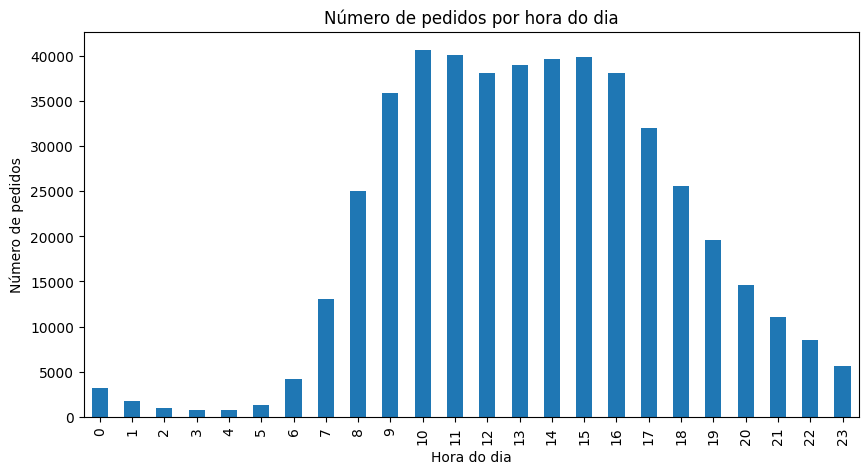

In [49]:
import matplotlib.pyplot as plt

instacart_orders['order_hour_of_day'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 5),
    title='Número de pedidos por hora do dia'
)

plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.show()

Escreva suas conclusões aqui

Esse gráfico mostra em quais horários do dia os pedidos são mais frequentes. Assim, dá para ver os períodos em que as pessoas costumam fazer mais compras.

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

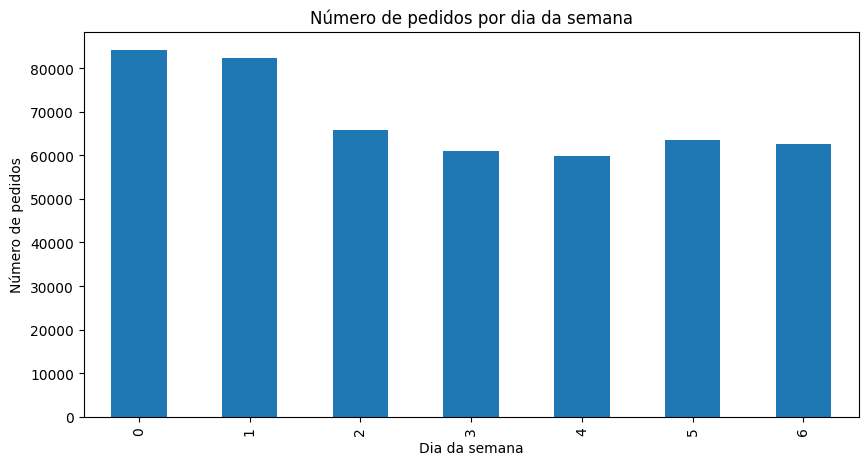

In [50]:
import matplotlib.pyplot as plt

instacart_orders['order_dow'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 5),
    title='Número de pedidos por dia da semana'
)

plt.xlabel('Dia da semana')
plt.ylabel('Número de pedidos')
plt.show()

Escreva suas conclusões aqui

Esse gráfico mostra em quais dias da semana os pedidos são mais frequentes. Assim, dá para identificar em que dias as pessoas costumam comprar mais produtos alimentícios.

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

Escreva suas conclusões aqui

O gráfico mostra em quantos dias as pessoas costumam fazer outro pedido. Os valores vão de 0 a 30 dias, e os mais comuns foram 30 e 7 dias. Isso sugere que muitos clientes fazem compras de forma mensal ou semanal.

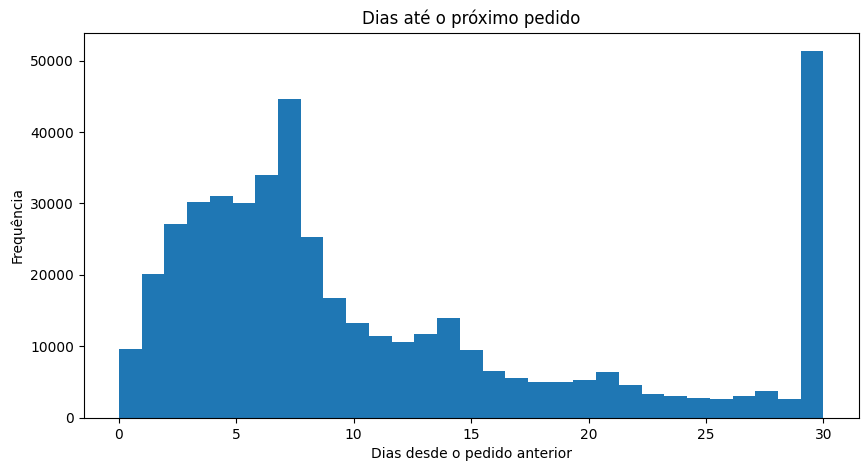

In [51]:
import matplotlib.pyplot as plt

instacart_orders['days_since_prior_order'].plot(
    kind='hist',
    bins=31,
    figsize=(10, 5),
    title='Dias até o próximo pedido'
)

plt.xlabel('Dias desde o pedido anterior')
plt.ylabel('Frequência')
plt.show()

# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

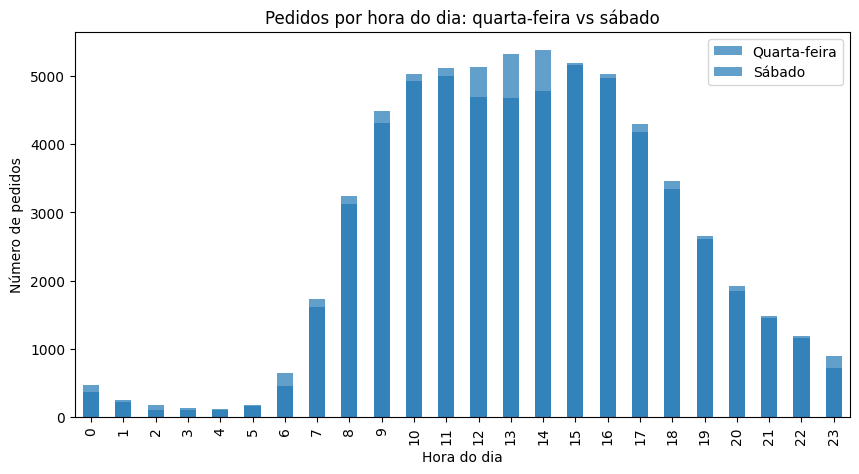

In [52]:
wed_orders = instacart_orders[instacart_orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
sat_orders = instacart_orders[instacart_orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
wed_orders.plot(kind='bar', alpha=0.7, label='Quarta-feira')
sat_orders.plot(kind='bar', alpha=0.7, label='Sábado')
plt.title('Pedidos por hora do dia: quarta-feira vs sábado')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.legend()
plt.show()

Escreva suas conclusões aqui

Esse gráfico compara a quantidade de pedidos por hora na quarta-feira e no sábado. Com ele, dá para ver se as pessoas fazem compras em horários diferentes nesses dois dias e identificar em qual deles os pedidos ficam mais concentrados ao longo do dia.

### [B2] Qual é a distribuição do número de pedidos por cliente?

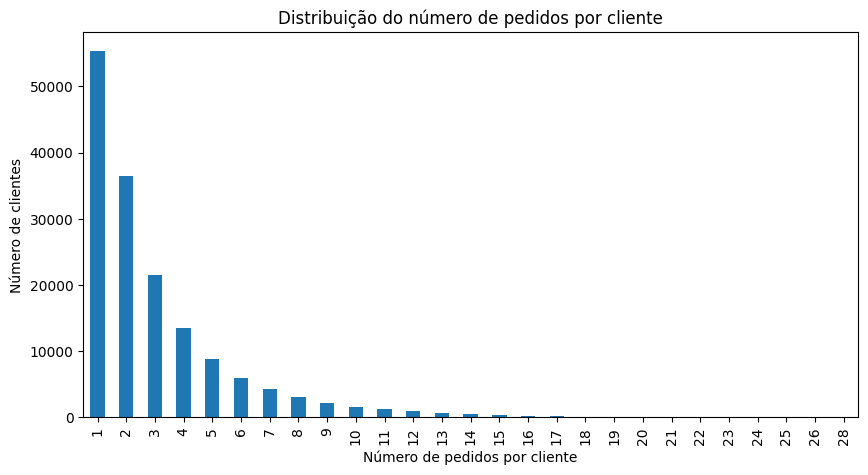

In [53]:
import matplotlib.pyplot as plt

orders_per_user = instacart_orders.groupby('user_id')['order_id'].count()

orders_per_user.value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 5),
    title='Distribuição do número de pedidos por cliente'
)

plt.xlabel('Número de pedidos por cliente')
plt.ylabel('Número de clientes')
plt.show()

Escreva suas conclusões aqui

Esse gráfico mostra quantos clientes fizeram 1 pedido, quantos fizeram 2, 3 e assim por diante. Assim, dá para entender melhor o comportamento dos clientes e ver se a maioria faz poucos ou muitos pedidos.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [54]:
top_20_products = (
    order_products.groupby('product_id')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='order_count')
    .merge(products[['product_id', 'product_name']], on='product_id', how='left')
)

top_20_products

,product_id,order_count,product_name
0,24852,66050,Banana
1,13176,53297,Bag of Organic Bananas
2,21137,37039,Organic Strawberries
3,21903,33971,Organic Baby Spinach
4,47209,29773,Organic Hass Avocado
5,47766,24689,Organic Avocado
6,47626,21495,Large Lemon
7,16797,20018,Strawberries
8,26209,19690,Limes
9,27845,19600,Organic Whole Milk


Escreva suas conclusões aqui

Esse resultado mostra quais são os 20 produtos mais comprados. Com ele, dá para ver quais itens aparecem com mais frequência nos pedidos e identificar os produtos mais populares.

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

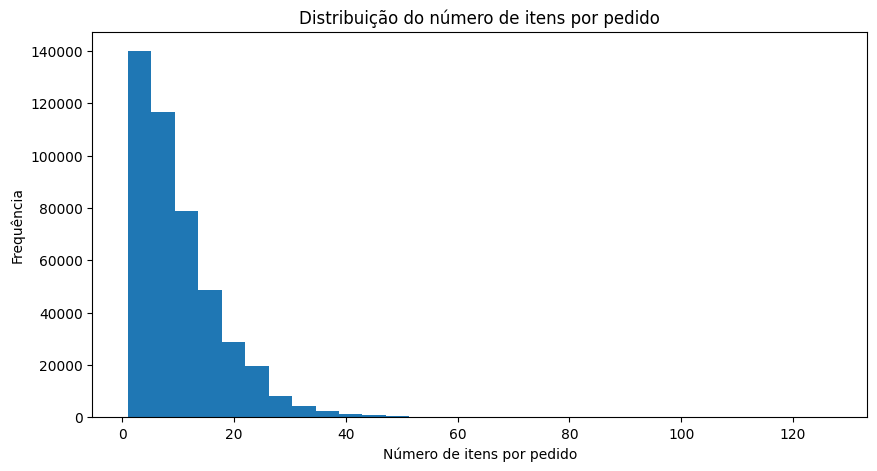

In [55]:
import matplotlib.pyplot as plt

items_per_order = order_products.groupby('order_id')['product_id'].count()

items_per_order.plot(
    kind='hist',
    bins=30,
    figsize=(10, 5),
    title='Distribuição do número de itens por pedido'
)

plt.xlabel('Número de itens por pedido')
plt.ylabel('Frequência')
plt.show()

Escreva suas conclusões aqui

Contei quantos produtos aparecem em cada pedido. Depois, fiz um gráfico para ver como esses valores se distribuem. Assim, dá para entender quantos itens as pessoas costumam comprar por pedido e se a maioria dos pedidos é pequena ou grande.

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [56]:
top_repeat_items = (
    order_products[order_products['reordered'] == 1]
    .groupby('product_id')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='repeat_count')
    .merge(products[['product_id', 'product_name']], on='product_id', how='left')
)

top_repeat_items

,product_id,repeat_count,product_name
0,24852,55763,Banana
1,13176,44450,Bag of Organic Bananas
2,21137,28639,Organic Strawberries
3,21903,26233,Organic Baby Spinach
4,47209,23629,Organic Hass Avocado
5,47766,18743,Organic Avocado
6,27845,16251,Organic Whole Milk
7,47626,15044,Large Lemon
8,27966,14748,Organic Raspberries
9,16797,13945,Strawberries


Escreva suas conclusões aqui

Essa tabela mostra os 20 produtos que aparecem com mais frequência em pedidos repetidos. Assim, dá para ver quais itens os clientes costumam comprar novamente com mais frequência.

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [57]:
product_repeat_rate = (
    order_products.groupby('product_id')['reordered']
    .mean()
    .reset_index(name='repeat_rate')
    .merge(products[['product_id', 'product_name']], on='product_id', how='left')
)

product_repeat_rate

,product_id,repeat_rate,product_name
0,1,0.564286,Chocolate Sandwich Cookies
1,2,0.000000,All-Seasons Salt
2,3,0.738095,Robust Golden Unsweetened Oolong Tea
3,4,0.510204,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,7,0.500000,Pure Coconut Water With Orange
...,...,...,...
45568,49690,0.800000,HIGH PERFORMANCE ENERGY DRINK
45569,49691,0.430556,ORIGINAL PANCAKE & WAFFLE MIX
45570,49692,0.416667,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
45571,49693,0.440000,SPRING WATER BODY WASH


Escreva suas conclusões aqui

Essa tabela mostra, para cada produto, a proporção de vezes em que ele foi comprado novamente. Como a coluna reordered tem valores 0 e 1, a média dela já representa essa proporção. Assim, dá para comparar quais produtos costumam ser repetidos com mais frequência.

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [58]:
user_repeat_rate = (
    instacart_orders.groupby('user_id')['order_number']
    .apply(lambda x: (x > 1).mean())
    .reset_index(name='repeat_rate')
)

user_repeat_rate

,user_id,repeat_rate
0,2,0.5
1,4,1.0
2,5,1.0
3,6,0.5
4,7,1.0
...,...,...
157432,206203,1.0
157433,206206,1.0
157434,206207,1.0
157435,206208,1.0


Escreva suas conclusões aqui

Essa tabela mostra, para cada cliente, a proporção de pedidos que não foram o primeiro. Assim, dá para entender com que frequência cada cliente volta a fazer novos pedidos.

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [59]:
top_first_cart_items = (
    order_products[order_products['add_to_cart_order'] == 1]
    .groupby('product_id')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='first_added_count')
    .merge(products[['product_id', 'product_name']], on='product_id', how='left')
)

top_first_cart_items

,product_id,first_added_count,product_name
0,24852,15562,Banana
1,13176,11026,Bag of Organic Bananas
2,27845,4363,Organic Whole Milk
3,21137,3946,Organic Strawberries
4,47209,3390,Organic Hass Avocado
5,21903,3336,Organic Baby Spinach
6,47766,3044,Organic Avocado
7,19660,2336,Spring Water
8,16797,2308,Strawberries
9,27966,2024,Organic Raspberries


Escreva suas conclusões aqui

Essa tabela mostra os 20 produtos que mais vezes foram o primeiro item adicionado ao carrinho. Assim, dá para identificar quais produtos costumam ser escolhidos logo no começo da compra.

# Conclusão geral do projeto:

No início do projeto, os dados tinham alguns problemas, como valores ausentes e linhas duplicadas. Para corrigir isso, removi os pedidos duplicados e tratei os valores ausentes nas colunas principais. Os nomes de produtos ausentes foram preenchidos com "Unknown" e os valores ausentes de add_to_cart_order foram substituídos por 999. Isso deixou os dados mais organizados para a análise.

Depois da limpeza, foi possível identificar alguns padrões de compra. Os pedidos se concentram principalmente entre 10h e 15h, com pico às 10h (40.578 pedidos). O dia com mais pedidos foi o domingo, com 84.090 pedidos. Também observei que o intervalo mais comum entre pedidos foi de 30 dias (51.337 ocorrências), seguido por 7 dias (44.577), o que sugere um padrão de compras mensais e semanais.

Entre os produtos, Banana foi o item mais comprado (66.050 pedidos) e também o mais recomprado (55.763 recompras). Outros produtos que também se destacaram foram Bag of Organic Bananas (44.450 recompras) e Organic Strawberries (28.639 recompras). No geral, os resultados mostram que produtos frescos e orgânicos aparecem bastante nas compras, o que pode ajudar a empresa a entender melhor o comportamento dos clientes e planejar ações mais estratégicas.